# Hospital Emergency Room Analysis

In [1]:
import pandas  as pd
import numpy as np
import matplotlib.pyplot as  plt 
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Hospital ER_Data.csv")
df.head()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0


In [3]:
df.tail()

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
9211,313-21-4953,28-08-2024 17:38,J,Spradbrow,NC,42,Asian,General Practice,True,NaN,43,0
9212,226-92-3412,28-06-2024 23:12,G,Antoniak,NC,19,Asian,NaN,True,NaN,49,0
9213,412-85-3832,16-05-2024 17:06,V,Riccardo,NC,14,Asian,NaN,True,NaN,36,0
9214,708-91-2439,14-05-2024 23:43,S,Renals,NC,73,Declined to Identify,General Practice,True,1.0,38,0
9215,249-47-9666,01-03-2024 08:50,Y,Greep,NC,35,White,General Practice,True,NaN,39,0


In [4]:
df.shape

(9216, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient First Inital        9216 non-null   object 
 3   Patient Last Name           9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   bool   
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
 11  Patients CM                 9216 non-null   int64  
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 801.1+ KB


In [6]:
df.columns

Index(['Patient Id', 'Patient Admission Date', 'Patient First Inital',
       'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime', 'Patients CM'],
      dtype='object')

In [7]:
df.isnull().sum()

Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Patients CM                      0
dtype: int64

In [8]:
df.duplicated().sum() 

np.int64(0)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Patient Age,9216.0,39.855143,22.755125,1.0,20.0,39.0,60.0,79.0
Patient Satisfaction Score,2517.0,4.992054,3.138043,0.0,2.0,5.0,8.0,10.0
Patient Waittime,9216.0,35.259874,14.735323,10.0,23.0,35.0,48.0,60.0
Patients CM,9216.0,0.052083,0.222207,0.0,0.0,0.0,0.0,1.0


####  Data Cleaning 

In [10]:
df["Patient Admission Date"]= pd.to_datetime(df["Patient Admission Date"],errors="coerce") 

In [11]:
df["Patient Admission Date"]

0      2024-03-20 08:47:00
1      2024-06-15 11:29:00
2      2024-06-20 09:13:00
3      2024-02-04 22:34:00
4      2024-09-04 17:48:00
               ...        
9211   2024-08-28 17:38:00
9212   2024-06-28 23:12:00
9213   2024-05-16 17:06:00
9214   2024-05-14 23:43:00
9215   2024-03-01 08:50:00
Name: Patient Admission Date, Length: 9216, dtype: datetime64[ns]

In [44]:
 # Convert column names to snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Convert data types
df["patient_admission_date"] = pd.to_datetime(df["patient_admission_date"], errors="coerce")
df["patient_age"] = pd.to_numeric(df["patient_age"], errors="coerce")
df["patient_waittime"] = pd.to_numeric(df["patient_waittime"], errors="coerce")

# Remove duplicates
df.drop_duplicates(inplace=True)



In [13]:
# Handle missing values
df.fillna({
    "patient_gender": "Unknown",
    "department_referral": "Unknown"
}, inplace=True)



In [14]:

df["patient_satisfaction_score"]=df["patient_satisfaction_score"].fillna(df["patient_satisfaction_score"].mean())

#### Feature Engineering

In [15]:
# Time features
df["year"] = df["patient_admission_date"].dt.year
df["month"] = df["patient_admission_date"].dt.month
df["day"] = df["patient_admission_date"].dt.day
df["hour"] = df["patient_admission_date"].dt.hour
df["Month_name"]=df["patient_admission_date"].dt.month_name()
df["weekday"]=df["patient_admission_date"].dt.day_name()
# Age Group
bins = [0, 12, 17, 35, 60, 120]
labels = ["Child", "Teen", "Adult", "Middle-Aged", "Senior"]
df["age_group"] = pd.cut(df["patient_age"], bins=bins, labels=labels)

# Wait Bucket
wt_bins = [-1, 30, 60, 120, float("inf")]
wt_labels = ["<30", "30-60", "60-120", ">120"]
df["wait_bucket"] = pd.cut(df["patient_waittime"], bins=wt_bins, labels=wt_labels)

# Repeat Patient
if "patient_id" in df.columns:
    freq = df["patient_id"].value_counts()
    df["is_repeat_patient"] = df["patient_id"].map(freq) > 1
 

### Exploratory Data Analysis (EDA)


In [45]:
df.describe()

,patient_admission_date,patient_age,patient_satisfaction_score,patient_waittime,patients_cm,year,month,day,hour
count,9216,9216.000000,9216.000000,9216.000000,9216.000000,9216.000000,9216.000000,9216.000000,9216.000000
mean,2024-01-16 14:21:23.372395776,39.855143,4.992054,35.259874,0.052083,2023.529297,6.674154,15.797635,11.486328
min,2023-04-01 01:13:00,1.000000,0.000000,10.000000,0.000000,2023.000000,1.000000,1.000000,0.000000
25%,2023-08-24 14:19:30,20.000000,4.992054,23.000000,0.000000,2023.000000,4.000000,8.000000,5.000000
50%,2024-01-17 06:50:30,39.000000,4.992054,35.000000,0.000000,2024.000000,7.000000,16.000000,11.000000
75%,2024-06-09 11:55:15,60.000000,4.992054,48.000000,0.000000,2024.000000,9.000000,23.000000,18.000000
max,2024-10-30 23:44:00,79.000000,10.000000,60.000000,1.000000,2024.000000,12.000000,31.000000,23.000000
std,NaN,22.755125,1.639708,14.735323,0.222207,0.499168,3.000606,8.818404,6.955110


In [46]:
numeric_cols = ["patient_age", "patient_satisfaction_score", "patient_waittime"]


####  Outliet Detaction 

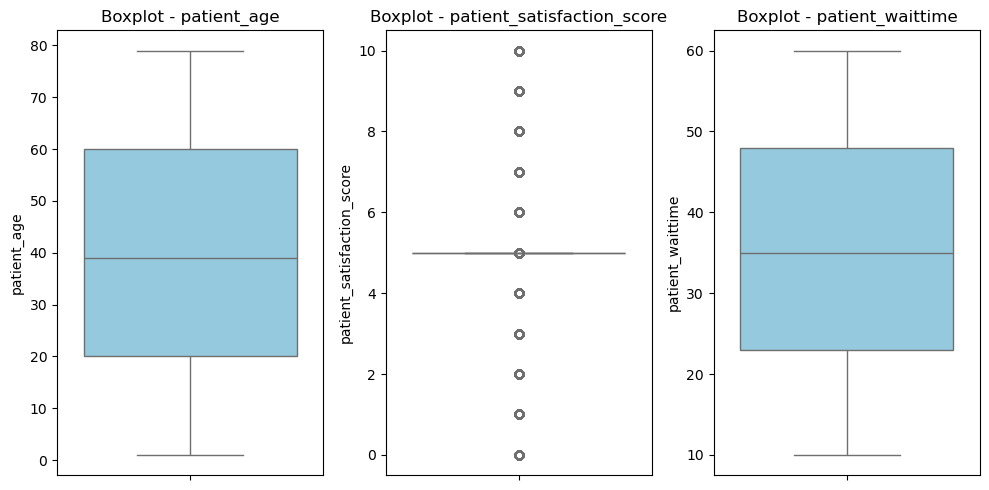

In [49]:
# Box Plot Visualization
plt.figure(figsize=(10, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df[col], color="skyblue")
    plt.title(f"Boxplot - {col}")
    plt.tight_layout()
plt.show()

In [50]:
 # IQR Method (Interquartile Range)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"\n{col}:")
    print(f"  Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
    print(f"  Lower Bound: {lower}, Upper Bound: {upper}")
    print(f"  Number of Outliers: {len(outliers)}")


patient_age:
  Q1: 20.0, Q3: 60.0, IQR: 40.0
  Lower Bound: -40.0, Upper Bound: 120.0
  Number of Outliers: 0

patient_satisfaction_score:
  Q1: 4.992054032578467, Q3: 4.992054032578467, IQR: 0.0
  Lower Bound: 4.992054032578467, Upper Bound: 4.992054032578467
  Number of Outliers: 2517

patient_waittime:
  Q1: 23.0, Q3: 48.0, IQR: 25.0
  Lower Bound: -14.5, Upper Bound: 85.5
  Number of Outliers: 0


### KPI's

In [16]:
total_patients = df["patient_id"].nunique()
avg_wait = df["patient_waittime"].mean()
avg_satisfaction = df["patient_satisfaction_score"].mean()
repeat_rate = df["is_repeat_patient"].mean() * 100
admission_rate = (df["patient_admission_flag"] == "Yes").mean() * 100

print("Total Patients:", total_patients)
print("Average Wait Time:", round(avg_wait, 2))
print("Avg Satisfaction:", round(avg_satisfaction, 2))
print("Repeat Patient %:", round(repeat_rate, 2))
print("Admission Rate %:", round(admission_rate, 2))

Total Patients: 9216
Average Wait Time: 35.26
Avg Satisfaction: 4.99
Repeat Patient %: 0.0
Admission Rate %: 0.0


#### Age Distribution

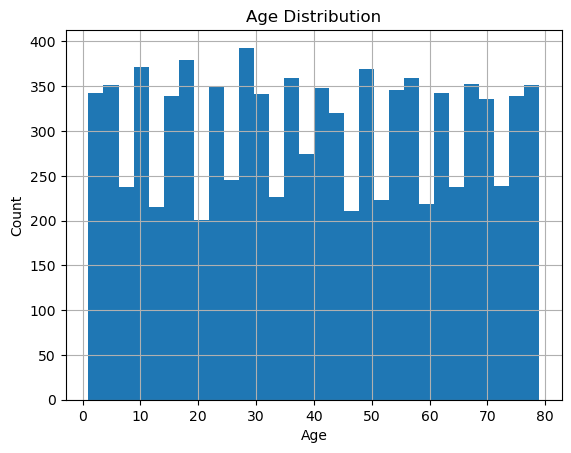

In [17]:
plt.figure()
df["patient_age"].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [18]:
# Gender Distribution
gender_count = df.groupby("patient_gender")["patient_id"].count()
print(gender_count)

patient_gender
F     4487
M     4705
NC      24
Name: patient_id, dtype: int64


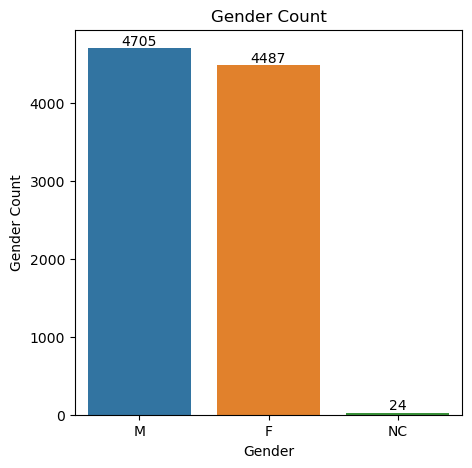

In [51]:
plt.figure(figsize=(5, 5))
ax = sns.countplot(x="patient_gender", data=df,hue="patient_gender")

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height(),
            int(p.get_height()), ha='center', va='bottom')

plt.title("Gender Count")
plt.xlabel("Gender")
plt.ylabel("Gender Count")
plt.show()

In [ ]:
# age_group Distribution 

In [20]:
Age_group_count = df.groupby("age_group")["patient_id"].count()
print(Age_group_count)

age_group
Child          1413
Teen            558
Adult          2124
Middle-Aged    2923
Senior         2198
Name: patient_id, dtype: int64


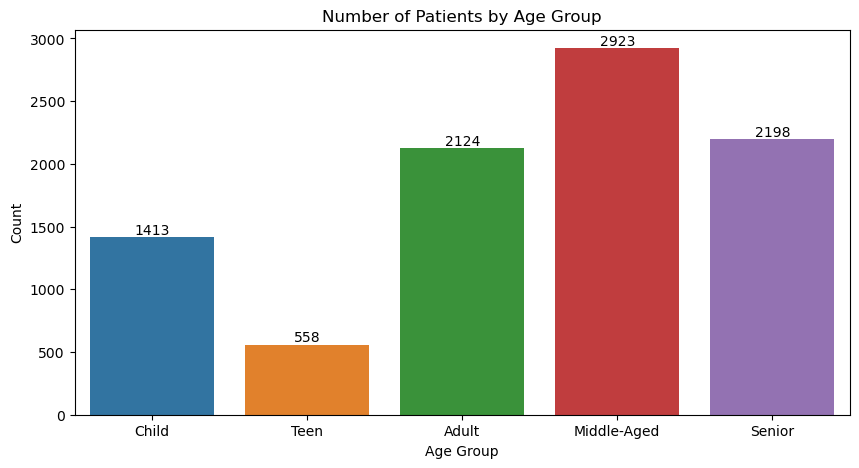

In [21]:
plt.figure(figsize=(10,5))

ax=sns.countplot(data=df, x="age_group",hue="age_group")

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height(),
            int(p.get_height()), ha='center', va='bottom')

plt.title("Number of Patients by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.show()

#### Department Referral


In [22]:
Dept_load=df.groupby("department_referral")["patient_id"].count()
Dept_load

department_referral
Cardiology           248
Gastroenterology     178
General Practice    1840
Neurology            193
Orthopedics          995
Physiotherapy        276
Renal                 86
Unknown             5400
Name: patient_id, dtype: int64

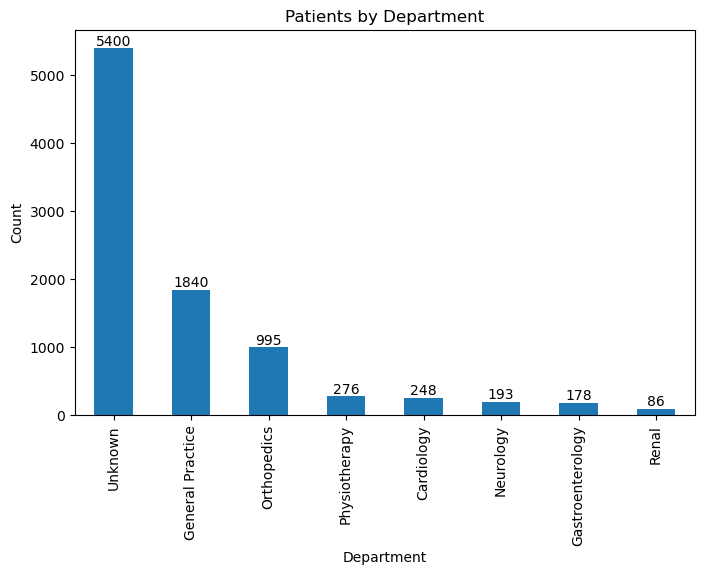

In [52]:
plt.figure(figsize=(8, 5))
ax = df["department_referral"].value_counts().plot(kind="bar")

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height(),
            int(p.get_height()), ha='center', va='bottom')

plt.title("Patients by Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

#### Wait bukect vs Satisfaction

In [24]:
wait_satisfaction = df.groupby("wait_bucket")["patient_satisfaction_score"].mean()
print(wait_satisfaction)


wait_bucket
<30       5.004862
30-60     4.983271
60-120         NaN
>120           NaN
Name: patient_satisfaction_score, dtype: float64


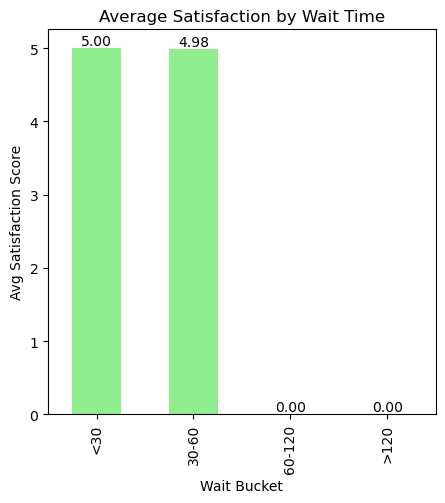

In [53]:
plt.figure(figsize=(5,5))

ax = wait_satisfaction.plot(kind="bar",color="lightgreen")

# Add data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Average Satisfaction by Wait Time")
plt.xlabel("Wait Bucket")
plt.ylabel("Avg Satisfaction Score")

plt.show()

#### Correlation Analysis

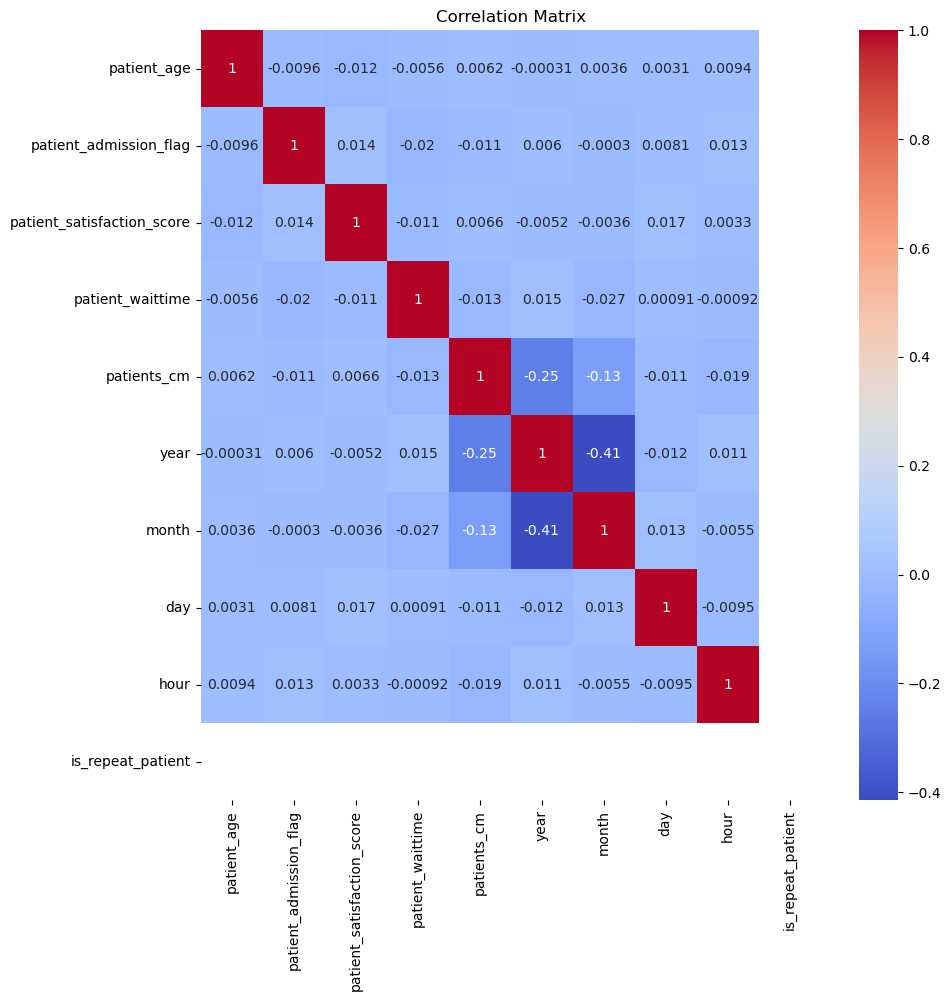

In [62]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

#### Avg Wait Time by Age Group

In [28]:
age_wait = df.groupby("age_group")["patient_waittime"].mean()
print(age_wait)

age_group
Child          35.302902
Teen           35.858423
Adult          35.356403
Middle-Aged    35.175847
Senior         35.098726
Name: patient_waittime, dtype: float64


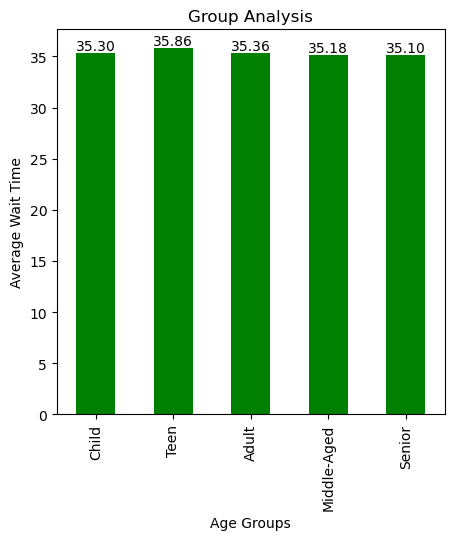

In [55]:
plt.figure(figsize=(5,5))

ax = age_wait.plot(kind="bar", color="g")

# Add labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')

plt.title("Group Analysis")
plt.xlabel("Age Groups")
plt.ylabel("Average Wait Time")

plt.show()


#### Satisfaction by Department

In [30]:
dept_sat = df.groupby("department_referral")["patient_satisfaction_score"].mean().sort_values(ascending=False)
print(dept_sat)

department_referral
Gastroenterology    5.236038
Neurology           5.071956
Cardiology          5.034651
General Practice    5.011074
Physiotherapy       4.990820
Unknown             4.981766
Orthopedics         4.953164
Renal               4.877900
Name: patient_satisfaction_score, dtype: float64


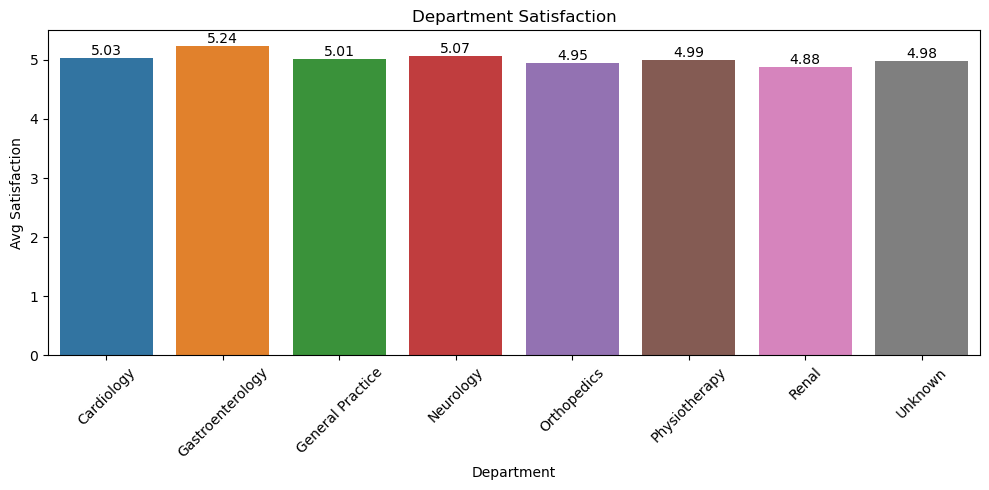

In [31]:
dept_sat = df.groupby("department_referral")["patient_satisfaction_score"].mean().reset_index()
dept_sat.columns = ["department_referral", "avg_satisfaction"]

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=dept_sat, x="department_referral", y="avg_satisfaction",hue="department_referral")

for p in ax.patches:
    ax.text(p.get_x() + p.get_width() / 2., p.get_height(),
            round(p.get_height(), 2), ha='center', va='bottom')

plt.title("Department Satisfaction")
plt.xlabel("Department")
plt.ylabel("Avg Satisfaction")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Time Trend Analysis

In [32]:
# Create Create monthly patient trend
# Group with month number + name
monthly_patient_trend = df.groupby(["year", "month", "Month_name"])["patient_id"] \
    .count() \
    .reset_index(name="patient_count")


print("Monthly Patient Admission")
print(monthly_patient_trend)


Monthly Patient Admission
    year  month Month_name  patient_count
0   2023      4      April            479
1   2023      5        May            480
2   2023      6       June            506
3   2023      7       July            464
4   2023      8     August            494
5   2023      9  September            469
6   2023     10    October            493
7   2023     11   November            464
8   2023     12   December            489
9   2024      1    January            513
10  2024      2   February            431
11  2024      3      March            506
12  2024      4      April            469
13  2024      5        May            519
14  2024      6       June            485
15  2024      7       July            488
16  2024      8     August            530
17  2024      9  September            466
18  2024     10    October            471


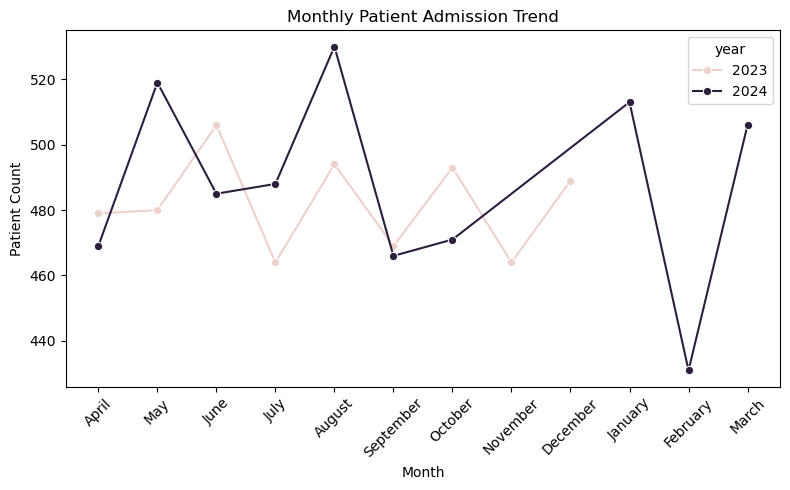

In [56]:
# Plot
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=monthly_patient_trend,
    x="Month_name",
    y="patient_count",
    hue="year",
    marker="o"
)

plt.title("Monthly Patient Admission Trend")
plt.xlabel("Month")
plt.ylabel("Patient Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

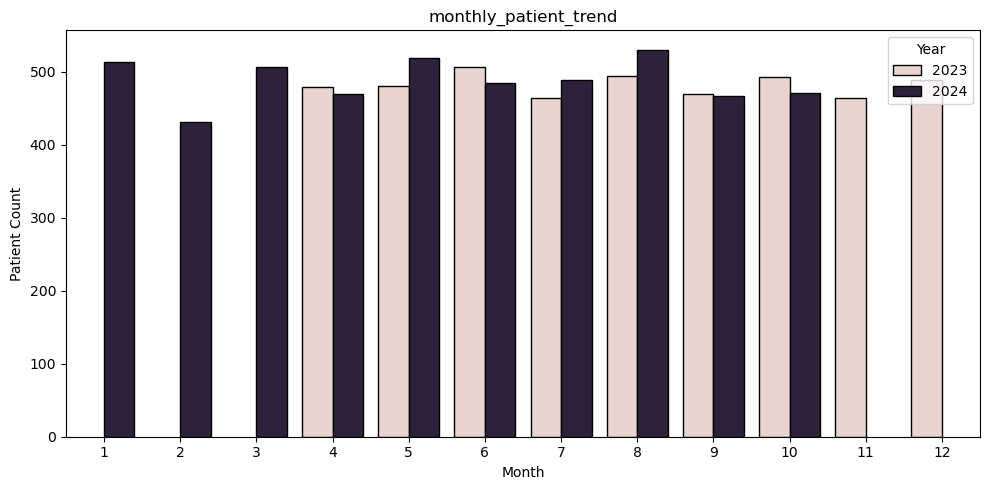

In [34]:
plt.figure(figsize=(10, 5))
sns.barplot(x="month", y="patient_count", hue="year", data=monthly_patient_trend,edgecolor="black")

plt.title("monthly_patient_trend")
plt.xlabel("Month")
plt.ylabel("Patient Count")
plt.xticks(ticks=range(0, 12), labels=range(1, 13))  # fixed xticks
plt.legend(title="Year")
plt.tight_layout()
plt.show()

### Weekly Trand 

In [35]:

weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Convert to categorical for proper sorting
df["weekday"] = pd.Categorical(df["weekday"], categories=weekday_order, ordered=True)

# Group and sort
daily_patient_trend = df.groupby("weekday")["patient_id"] \
    .count() \
    .reset_index(name="patient_count") \
    .sort_values("weekday")

print("Daily Patient Admission")
print(daily_patient_trend)


Daily Patient Admission
     weekday  patient_count
0     Monday           1314
1    Tuesday           1305
2  Wednesday           1260
3   Thursday           1332
4     Friday           1310
5   Saturday           1377
6     Sunday           1318


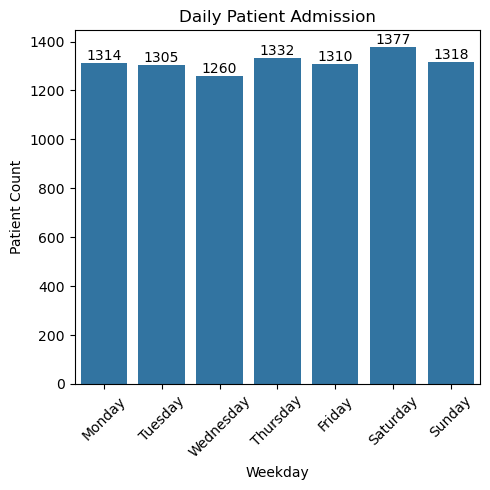

In [57]:
plt.figure(figsize=(5,5))

ax = sns.barplot(
    data=daily_patient_trend,
    x="weekday",
    y="patient_count"
)

# Add data labels
for index, row in daily_patient_trend.iterrows():
    ax.text(
        index, 
        row["patient_count"], 
        str(row["patient_count"]), 
        ha='center', 
        va='bottom'
    )

plt.title("Daily Patient Admission")
plt.xlabel("Weekday")
plt.ylabel("Patient Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [37]:

# Create 
bins = [0, 6, 12, 18, 24]
labels = ["Night (0-6)", "Morning (6-12)", "Afternoon (12-18)", "Evening (18-24)"]

df["hour_range"] = pd.cut(df["hour"], bins=bins, labels=labels, right=False)

# Group data
hourly_range_trend = df.groupby("hour_range")["patient_id"] \
    .count() \
    .reset_index(name="patient_count")

print("Patient Admission by Time Range")
print(hourly_range_trend)

Patient Admission by Time Range
          hour_range  patient_count
0        Night (0-6)           2316
1     Morning (6-12)           2316
2  Afternoon (12-18)           2275
3    Evening (18-24)           2309


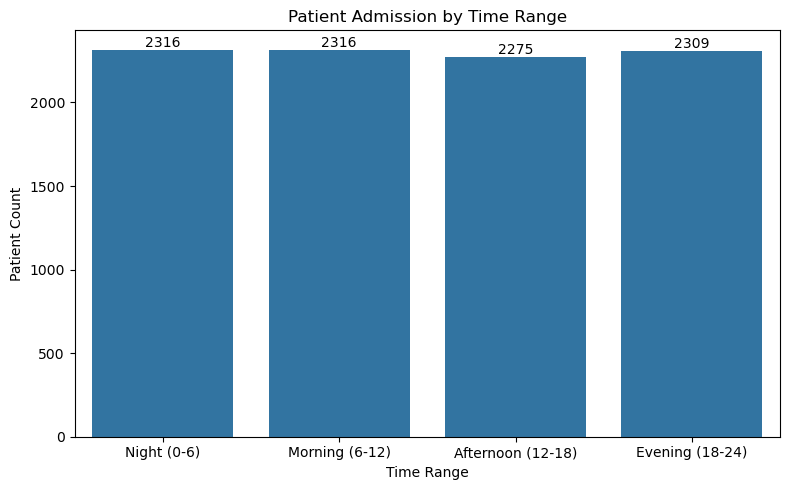

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=hourly_range_trend,
    x="hour_range",
    y="patient_count"
)

# Add data labels
for i, v in enumerate(hourly_range_trend["patient_count"]):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title("Patient Admission by Time Range")
plt.xlabel("Time Range")
plt.ylabel("Patient Count")

plt.tight_layout()
plt.show()